In [1]:
# import libraries and other configurations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

warnings.filterwarnings("ignore")

RANDOM_STATE = 121

In [2]:
# Load dataset
df = pd.read_csv(
    "../data/processed/cleaned_donor_data.csv",
)

In [3]:
# Verify dataset loaded correctly
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (34403, 19)


,donor_unique_id,donor_postal_code,donor_age,gender_identity,is_member_flag,is_alumnus_flag,is_parent_flag,has_involvement_flag,preferred_address_type,has_email_flag,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,donor_indicator_flag
0,1,23187.0,42,Female,0,0,0,0,Home,0,1,0.0,0.0,0.0,0.0,0.0,0.0,10.0,1
1,2,77643.0,33,Female,0,1,0,1,NaN,1,0,0.0,0.0,0.0,0.0,0.0,0.0,2100.0,1
2,3,NaN,42,Female,0,0,0,0,Home,0,1,0.0,0.0,0.0,0.0,0.0,200.0,200.0,1
3,4,47141.0,31,Female,0,1,0,1,Home,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,92555.0,68,Female,0,0,0,0,Home,1,0,0.0,0.0,0.0,0.0,0.0,0.0,505.0,1


In [4]:
# Verify dataset loaded correctly
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   donor_unique_id               34403 non-null  int64  
 1   donor_postal_code             34312 non-null  float64
 2   donor_age                     34403 non-null  int64  
 3   gender_identity               33912 non-null  str    
 4   is_member_flag                34403 non-null  int64  
 5   is_alumnus_flag               34403 non-null  int64  
 6   is_parent_flag                34403 non-null  int64  
 7   has_involvement_flag          34403 non-null  int64  
 8   preferred_address_type        30370 non-null  str    
 9   has_email_flag                34403 non-null  int64  
 10  consecutive_donor_years       34403 non-null  int64  
 11  last_fiscal_year_donation     34403 non-null  float64
 12  donation_2_fiscal_years_ago   34403 non-null  float64
 13  donation_3_f

In [5]:
# Verify dataset loaded correctly
df.sample(10, random_state=RANDOM_STATE)

,donor_unique_id,donor_postal_code,donor_age,gender_identity,is_member_flag,is_alumnus_flag,is_parent_flag,has_involvement_flag,preferred_address_type,has_email_flag,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,donor_indicator_flag
33267,33371,42301.0,46,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
26595,26683,45620.0,42,Female,0,0,0,0,Home,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
16653,16704,33427.0,28,Female,0,0,0,0,Home,0,0,0.0,120.0,0.0,0.0,0.0,0.0,120.0,1
21428,21498,54131.0,33,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
16873,16924,90265.0,33,Male,0,1,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19919,19982,54459.0,32,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
15478,15527,64686.0,42,Male,0,0,0,0,Home,0,8,0.0,0.0,10.0,0.0,0.0,0.0,9680.0,1
591,596,12067.0,42,Female,0,0,1,0,Home,0,0,0.0,100.0,1.0,0.0,0.0,0.0,101.0,1
1474,1483,90265.0,42,Female,0,1,0,0,Home,1,0,0.0,0.0,0.0,0.0,0.0,0.0,479.0,1
22846,22922,45856.0,36,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [6]:
# Verify dataset loaded correctly
df.isna().sum().sort_values(ascending=False).head(10)

preferred_address_type          4033
gender_identity                  491
donor_postal_code                 91
donor_unique_id                    0
last_fiscal_year_donation          0
cumulative_donation_amount         0
current_fiscal_year_donation       0
donation_5_fiscal_years_ago        0
donation_4_fiscal_years_ago        0
donation_3_fiscal_years_ago        0
dtype: int64

In [7]:
# Dataset Shape
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 34,403
Columns: 19


In [8]:
# Data Types Summary
dtype_summary = (
    df.dtypes
      .astype(str)
      .value_counts()
      .reset_index()
)

dtype_summary.columns = ["Data Type", "Count"]
dtype_summary

,Data Type,Count
0,int64,9
1,float64,8
2,str,2


In [9]:
# Numerical Variables
numeric_cols = df.select_dtypes(
    include=["int64", "float64", "Int64"]
).columns.tolist()

print(f"Numeric Variables: {len(numeric_cols)}")
print("-" * 40)
print(numeric_cols)

Numeric Variables: 17
----------------------------------------
['donor_unique_id', 'donor_postal_code', 'donor_age', 'is_member_flag', 'is_alumnus_flag', 'is_parent_flag', 'has_involvement_flag', 'has_email_flag', 'consecutive_donor_years', 'last_fiscal_year_donation', 'donation_2_fiscal_years_ago', 'donation_3_fiscal_years_ago', 'donation_4_fiscal_years_ago', 'donation_5_fiscal_years_ago', 'current_fiscal_year_donation', 'cumulative_donation_amount', 'donor_indicator_flag']


In [10]:
# Categorical Variables
categorical_cols = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print(f"Categorical Variables: {len(categorical_cols)}")
print("-" * 40)
print(categorical_cols)

Categorical Variables: 2
----------------------------------------
['gender_identity', 'preferred_address_type']


In [11]:
# Memory Usage
memory_mb = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage: {memory_mb:.2f} MB")

Memory Usage: 5.28 MB


## Dataset Overview Observations

### Dataset Summary
- The cleaned dataset contains 34,403 donor records and 19 features.
- Compared to the original dataset, 105 records were removed during cleaning and four features were removed due to excessive missingness.

### Feature Composition
- The dataset contains a mixture of demographic information, engagement indicators, donor history variables, and donation amount variables.
- Most variables are numerical due to the conversion of binary `Y/N` indicators into '1/0' values during data cleaning.

### EDA Focus
- The primary goal of this phase is to identify patterns within donor demographics, engagement behavior, and historical donation activity that may help inform future donor propensity modeling and business outreach strategies.

In [12]:
# Historical Donor Distribution Counts
donor_status_counts = df["donor_indicator_flag"].value_counts()

donor_status_counts

donor_indicator_flag
1    21369
0    13034
Name: count, dtype: int64

In [13]:
# Historical Donor Distribution Percentage
donor_status_pct = (
    df["donor_indicator_flag"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

donor_status_pct

donor_indicator_flag
0    37.89
1    62.11
Name: proportion, dtype: float64

In [14]:
# Historical Donor Distribution Summary
donor_status_summary = pd.DataFrame({
    "Count": df["donor_indicator_flag"].value_counts(),
    "Percent": (
        df["donor_indicator_flag"]
        .value_counts(normalize=True)
        .map(lambda x: f"{x * 100:.2f}%")
    ).round(2)
})

donor_status_summary

,Count,Percent
donor_indicator_flag,,
1,21369,62.11%
0,13034,37.89%


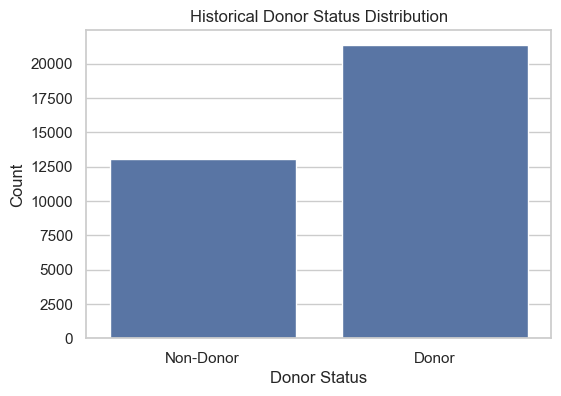

In [15]:
# Historical Donor Distribution Count Bar Graph
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="donor_indicator_flag"
)

plt.xticks(
    [0,1],
    ["Non-Donor","Donor"]
)

plt.title("Historical Donor Status Distribution")
plt.xlabel("Donor Status")
plt.ylabel("Count")

plt.show()

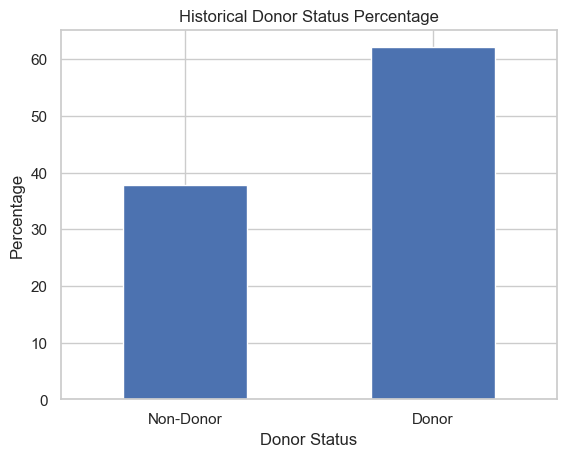

In [16]:
# Historical Donor Distribution Percentage Bar Graph
donor_status_pct.plot(
    kind="bar"
)

plt.title("Historical Donor Status Percentage")
plt.xlabel("Donor Status")
plt.ylabel("Percentage")

plt.xticks(
    [0,1],
    ["Non-Donor","Donor"],
    rotation=0
)

plt.show()

## Historical Donor Status Observations

- Approximately 62.11% of constituents in the dataset are classified as historical donors, while 37.89% are non-donors. 
- While historical donors make up the majority of the dataset, both groups are well-represented. The strong sample size ensures that any comparisons we make during analysis will be highly reliable and statistically sound.